# I. Introduction

---
## Background
The energy market has undergone massive transformation—new players in the market have increased competition, new pricing models have given customers more flexibility, and a shift toward renewable energy have forced legacy utility companies to invest in new technologies. With more energy providers offering flexible rates, clean energy alternatives, and digital-first customer experiences, PowerCo has been losing customers to their competitors at a higher-than-average rate, eating into margins and threatening long-term growth.

## Objective
The main objective of this project is identify what kind of customers which could churn so that PowerCo could understand their customers and prevent them to move out from PowerCo services

# II. Exploratory Data Analysis
---
## a. Import Packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
from scipy.stats import spearmanr
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer                              
from sklearn.pipeline import make_pipeline                        
from sklearn.metrics import classification_report, ConfusionMatrixDisplay 
from feature_engine.outliers import Winsorizer                                
from sklearn.metrics import roc_curve, roc_auc_score                       
import dill                                                                                 
from sklearn.decomposition import PCA                                                           
from sklearn.neighbors import KNeighborsClassifier                                              
from sklearn.svm import SVC                                                                         
from sklearn.tree import DecisionTreeClassifier                                                  
from sklearn.ensemble import RandomForestClassifier                                                
from xgboost import XGBClassifier                                                                   
from imblearn.over_sampling import SMOTENC                                                         
from imblearn.pipeline import make_pipeline as imbl_make_pipeline   
import shap                                

## b. Loading data with Pandas

In [2]:
client_df = pd.read_csv('client_data.csv') 
price_df = pd.read_csv('price_data.csv')
client_df

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,...,t,0.00,27.88,27.88,2,381.77,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,0
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,...,f,15.94,0.00,0.00,1,90.34,3,lxidpiddsbxsbosboudacockeimpuepw,6.000,1
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,...,f,18.05,39.84,39.84,1,20.38,4,lxidpiddsbxsbosboudacockeimpuepw,15.935,1
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,...,f,0.00,13.08,13.08,1,0.96,3,lxidpiddsbxsbosboudacockeimpuepw,11.000,0


In [3]:
price_df

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.000000,0.000000,44.266931,0.00000,0.000000
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.000000,0.000000,44.266931,0.00000,0.000000
...,...,...,...,...,...,...,...,...
192997,16f51cdc2baa19af0b940ee1b3dd17d5,2015-08-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192998,16f51cdc2baa19af0b940ee1b3dd17d5,2015-09-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
192999,16f51cdc2baa19af0b940ee1b3dd17d5,2015-10-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555
193000,16f51cdc2baa19af0b940ee1b3dd17d5,2015-11-01,0.119916,0.102232,0.076257,40.728885,24.43733,16.291555


## c. Descriptive Statistics of Data
---
### Data types

In [4]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [5]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


### Statistics
---

In [6]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [7]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


## d. Data visualization

In [8]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    annotate_stacked_bars(ax, textsize=14)
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, colour="white", textsize=13):
    for p in ax.patches:
        # Mengambil tinggi bar (nilai persentase)
        height = p.get_height()
        value = str(round(height, 1))
        
        # Abaikan jika nilai 0 agar tidak menumpuk di dasar
        if height <= 0:
            continue
            
        # Menghitung titik tengah (center) secara presisi
        x_pos = p.get_x() + p.get_width() / 2
        y_pos = p.get_y() + height / 2
        
        ax.annotate(
            value,
            (x_pos, y_pos),
            color=colour,
            size=textsize,
            ha='center', # Horizontal alignment: tengah
            va='center', # Vertical alignment: tengah
            fontweight='bold' # Opsional: agar lebih jelas dibaca
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    ax.set_xlabel(column)
    ax.ticklabel_format(style='plain', axis='x')

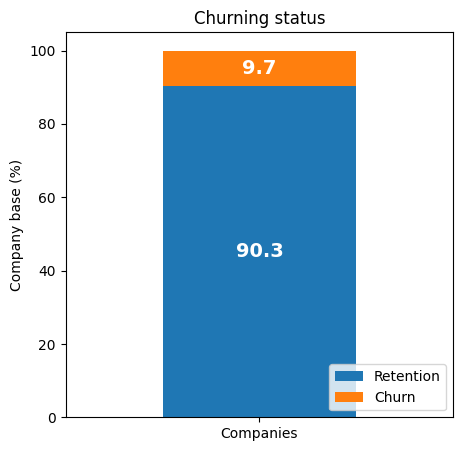

In [9]:
df_eda = client_df.copy()
churn = df_eda[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

The churn rate is 9.7% which is considerable rate.

---
### Sales Channel

In [10]:
# Checking Unique Values on Each Dataset
print(f"Number of Channel Sales Category {df_eda['channel_sales'].nunique()}")
print(f"Number of Customer Origin Category {df_eda['origin_up'].nunique()}")
print(df_eda['channel_sales'].value_counts())
print(df_eda['origin_up'].value_counts())

Number of Channel Sales Category 8
Number of Customer Origin Category 6
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64


In [11]:
channel_mapping = {
        'foosdfpfkusacimwkcsosbicdxkicaua': 'Direct Sales',
        'usilxuppasemubllopkaafesmlibmsdf': 'Online',
        'lmkebamcaaclubfxadlmueccxoimlema': 'Broker',
        'ewpakwlliwisiwduibdlfmalxowmwpci': 'Telesales',
        'epumfxlbckeskwekxbiuasklxalciiuu': 'Partnership',
        'fixdbufsefwooaasfcxdxadsiekoceaa': 'Corporate',
        'sddiedcslfslkckwlfkdpoeeailfpeds': 'SME Sales',
        'MISSING': 'Unknown'
    }
df_eda['channel_sales'] = df_eda['channel_sales'].replace(channel_mapping)

origin_mapping = {
        'kamkkxfxxuwbdslkwifmmcsiusiuosws': 'A',
        'lxidpiddsbxsbosboudacockeimpuepw': 'B',
        'ldkssxwpmemidmecebumciepifcamkci': 'C',
        'MISSING': 'D',
        'usapbepcfoloekilkwsdiboslwaxobdp': 'E',
        'ewxeelcelemmiwuafmddpobolfuxioce': 'F'
    }
df_eda['origin_up'] = df_eda['origin_up'].replace(origin_mapping)

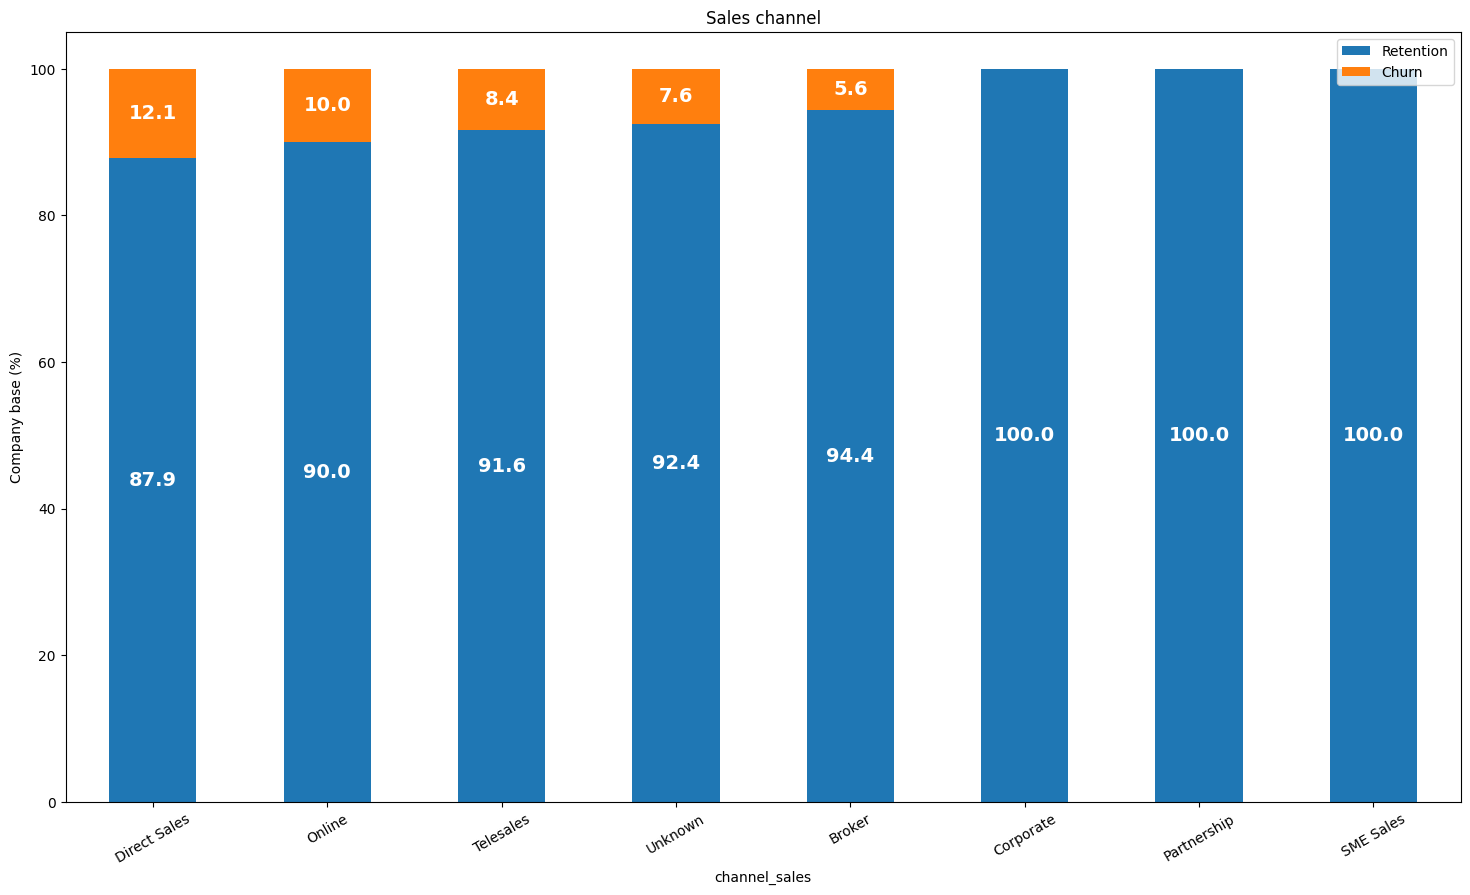

In [12]:
channel = df_eda[['id', 'channel_sales', 'churn']]
channel = channel.groupby([channel['channel_sales'], channel['churn']])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
plot_stacked_bars(channel_churn, 'Sales channel', rot_=30)

From 8 channels, there are 5 channel contributed to the churn rate and 3 channel not. It could be a good feature for separating and modelling churn rate.

---
### Contract Type

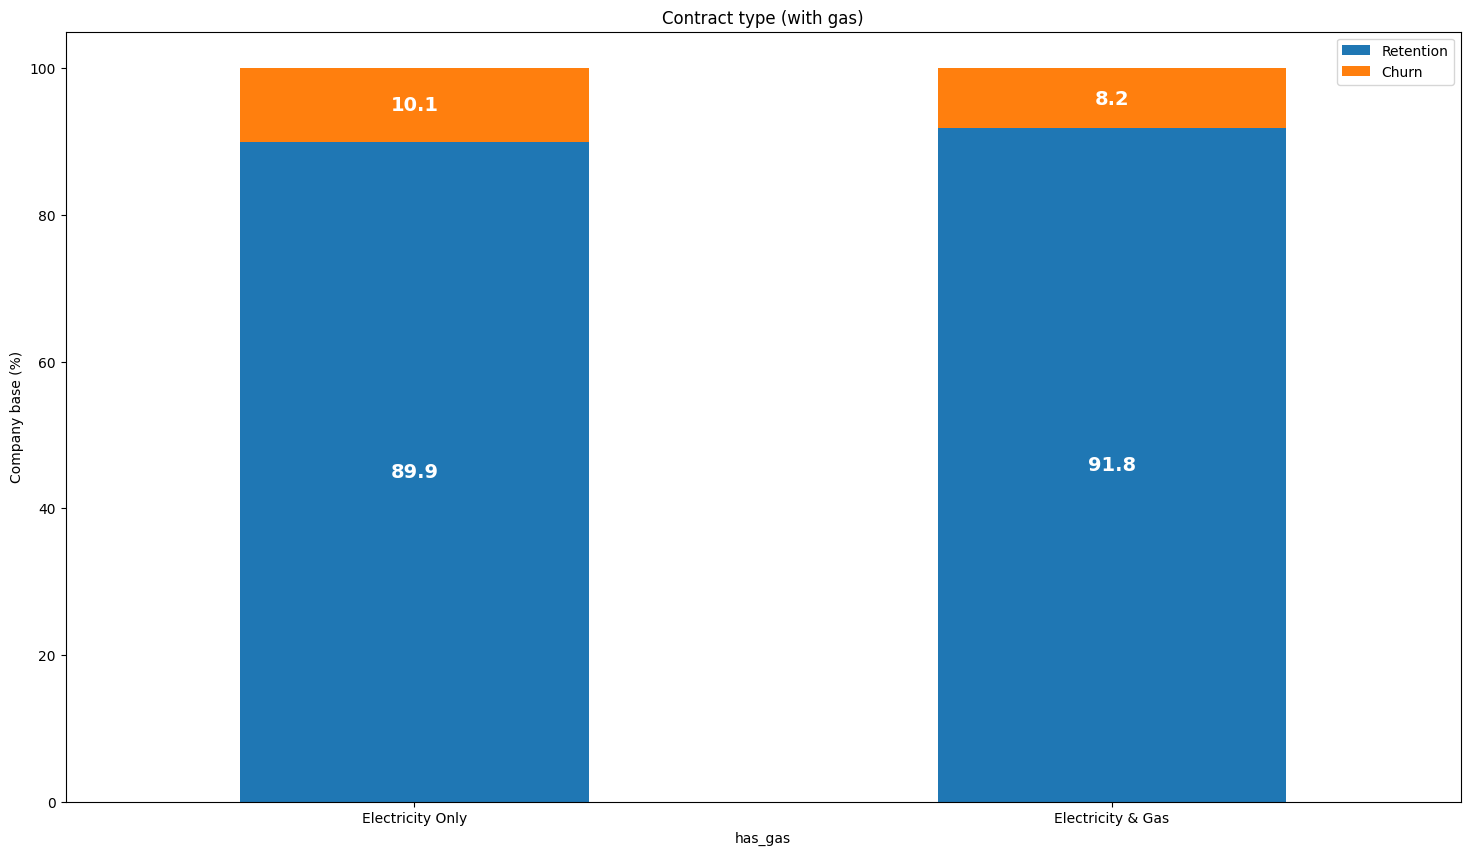

In [13]:
contract_type = df_eda[['id', 'has_gas', 'churn']]
contract = contract_type.groupby([contract_type['churn'], contract_type['has_gas']])['id'].count().unstack(level=0)
contract.rename(index={'f': 'Electricity Only', 't': 'Electricity & Gas'}, inplace=True)
contract_percentage = (contract.div(contract.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
plot_stacked_bars(contract_percentage, 'Contract type (with gas)')

There is no big differences between each contract type. The proportion of churn rate is on the same level.

---
### Number of Active Product

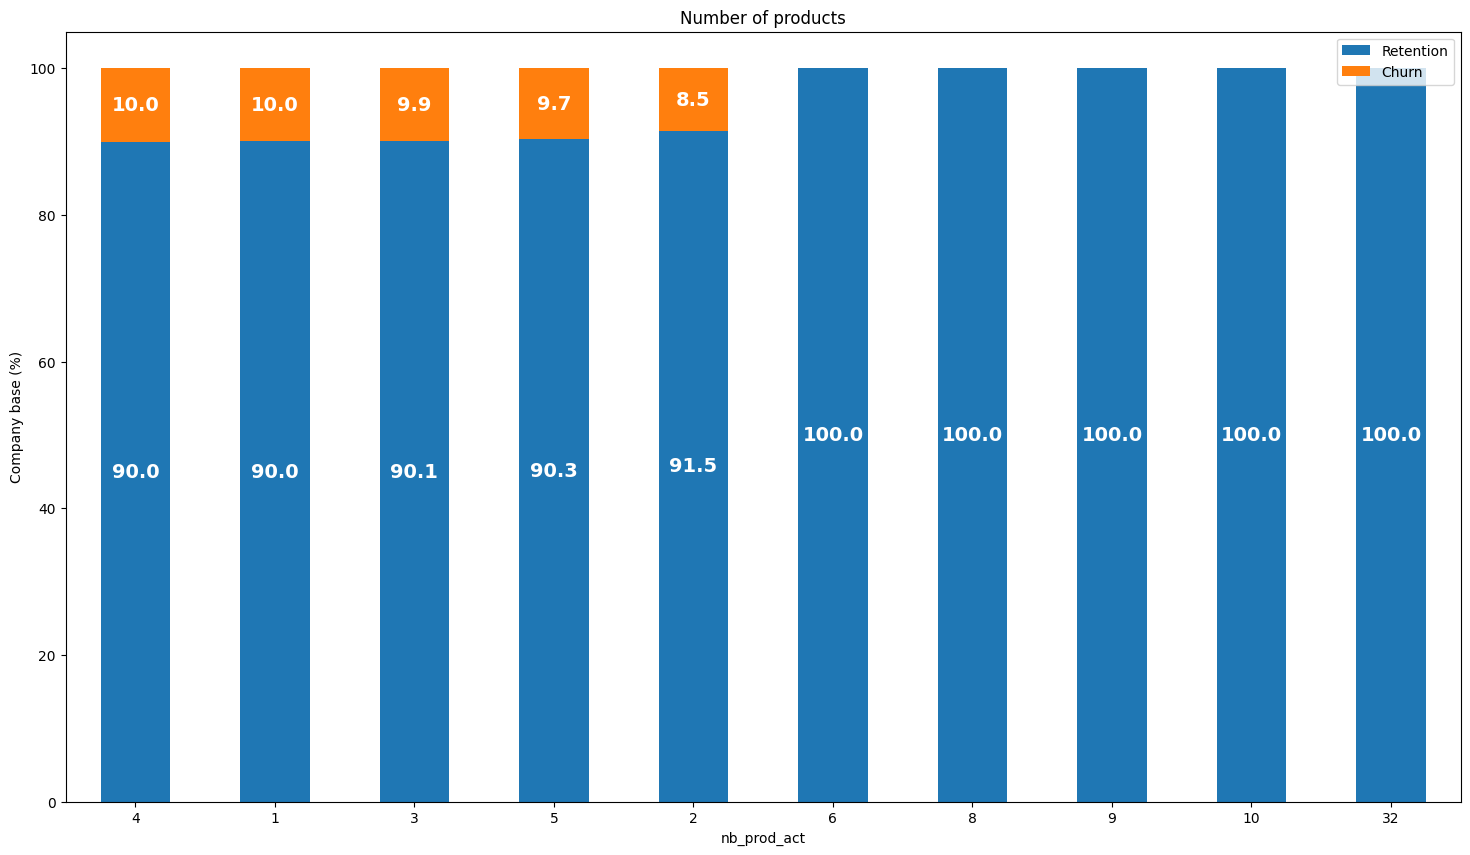

In [14]:
others = df_eda[['id', 'nb_prod_act', 'num_years_antig', 'origin_up', 'churn']]
products = others.groupby([others["nb_prod_act"],others["churn"]])["id"].count().unstack(level=1)
products_percentage = (products.div(products.sum(axis=1), axis=0)*100).sort_values(by=[1], ascending=False)
plot_stacked_bars(products_percentage, "Number of products")

As we can see, customers with less than 6 have a similar churn rate. However, the number of active product more than 5 have not churn at all.

---
### Customer Tenure

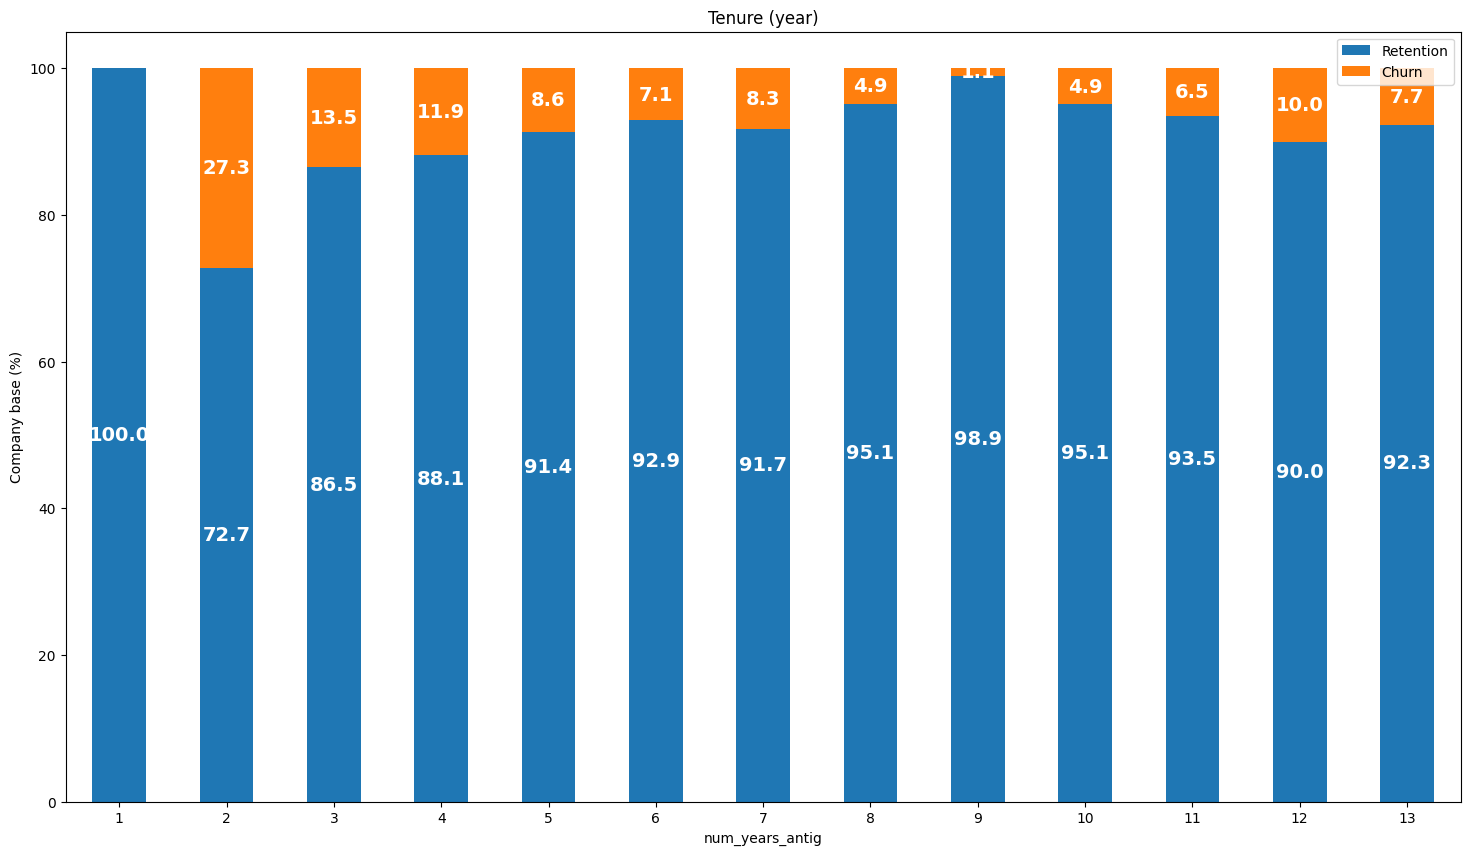

In [15]:
years_antig = others.groupby([others["num_years_antig"],others["churn"]])["id"].count().unstack(level=1)
years_antig_percentage = (years_antig.div(years_antig.sum(axis=1), axis=0)*100)
plot_stacked_bars(years_antig_percentage, "Tenure (year)")

Between 1-13 years customer duration, the highest churn happened on their second year, almost a third and customer churn still existed on the group of 3-13 year. For the first year, there is no churn at all. It could be happen because they are not fully consider to move their subscription. 

---
### Origin of Customers

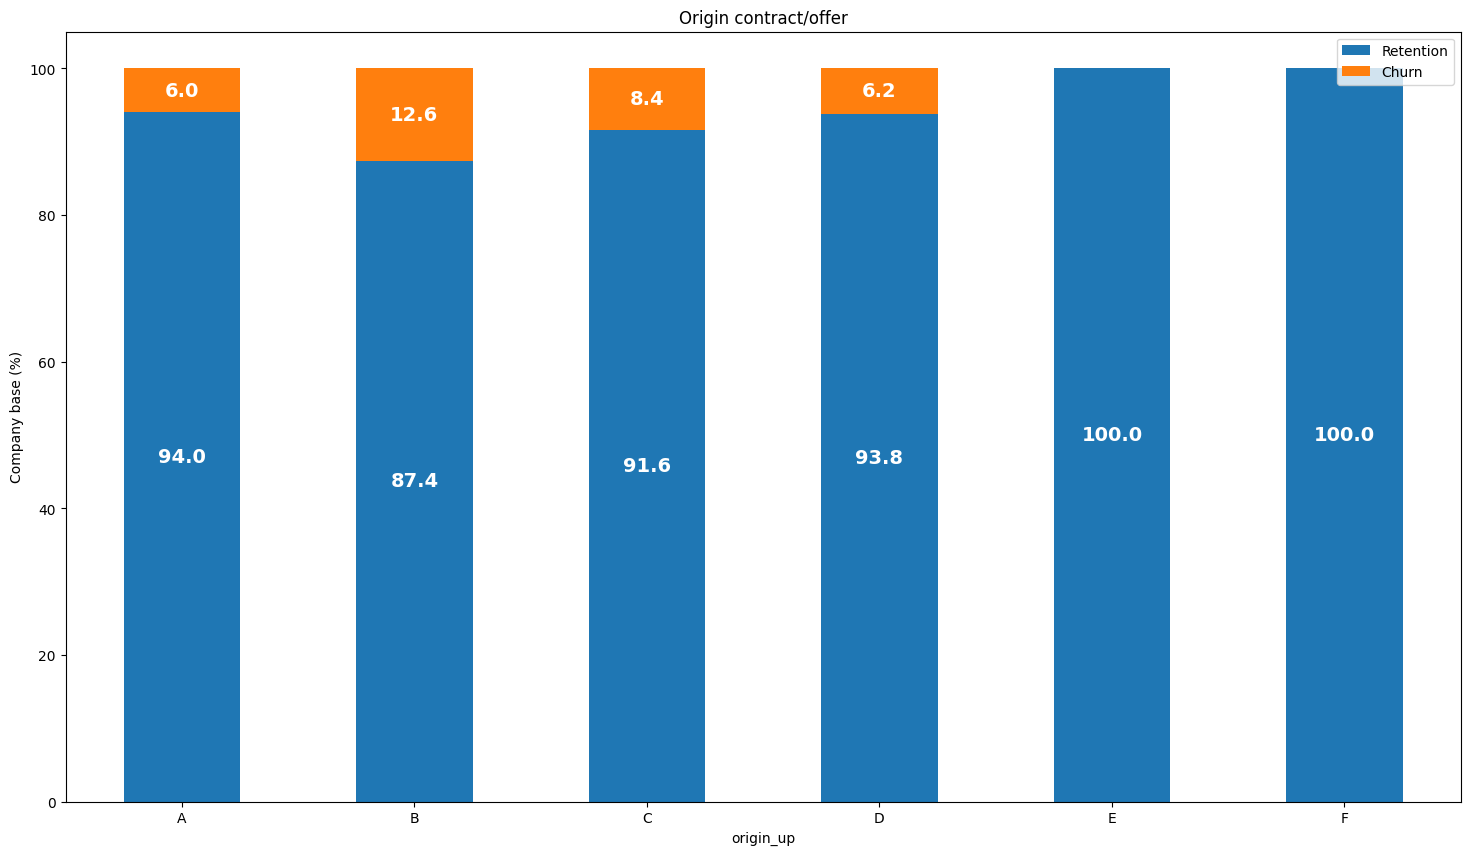

In [16]:
origin = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stacked_bars(origin_percentage, "Origin contract/offer")

From 6 campaign, customers churning came from 4 campaigns and 2 campaigns left are still loyal.

---
### Consumption Features

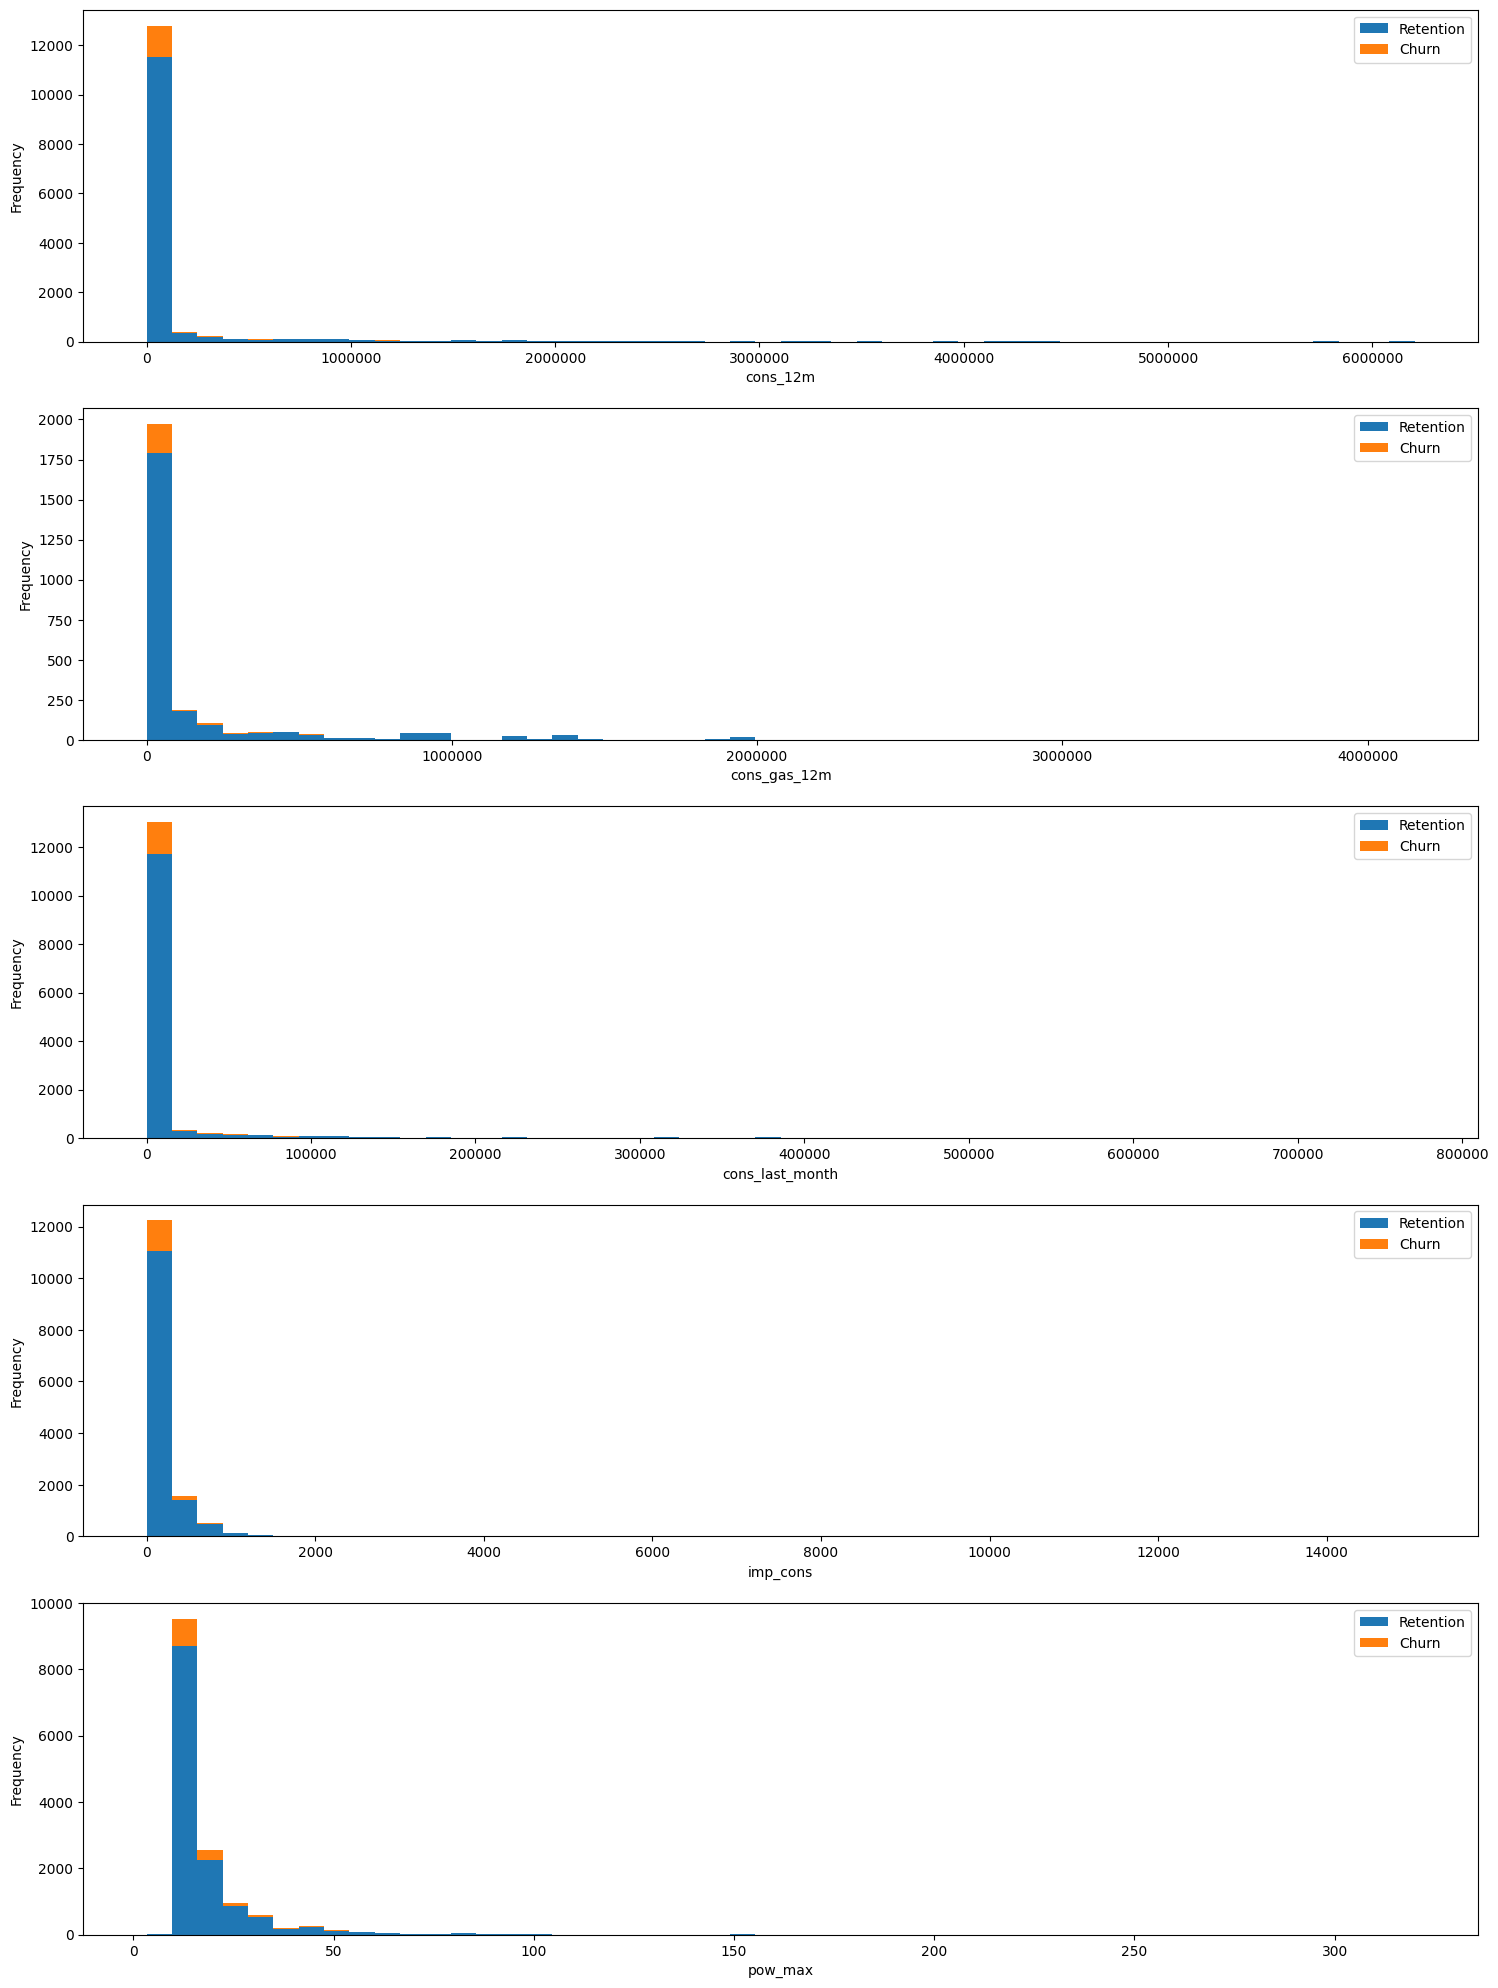

In [17]:
# Visualizing Distribution of Consumption Features
consumption = df_eda[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'pow_max','has_gas', 'churn']]
fig, axs = plt.subplots(nrows=5, figsize=(18, 25))
plot_distribution(consumption, 'cons_12m', axs[0])
plot_distribution(consumption[consumption['has_gas'] == 't'], 'cons_gas_12m', axs[1])
plot_distribution(consumption, 'cons_last_month', axs[2])
plot_distribution(consumption, 'imp_cons', axs[3])
plot_distribution(consumption, 'pow_max', axs[4])

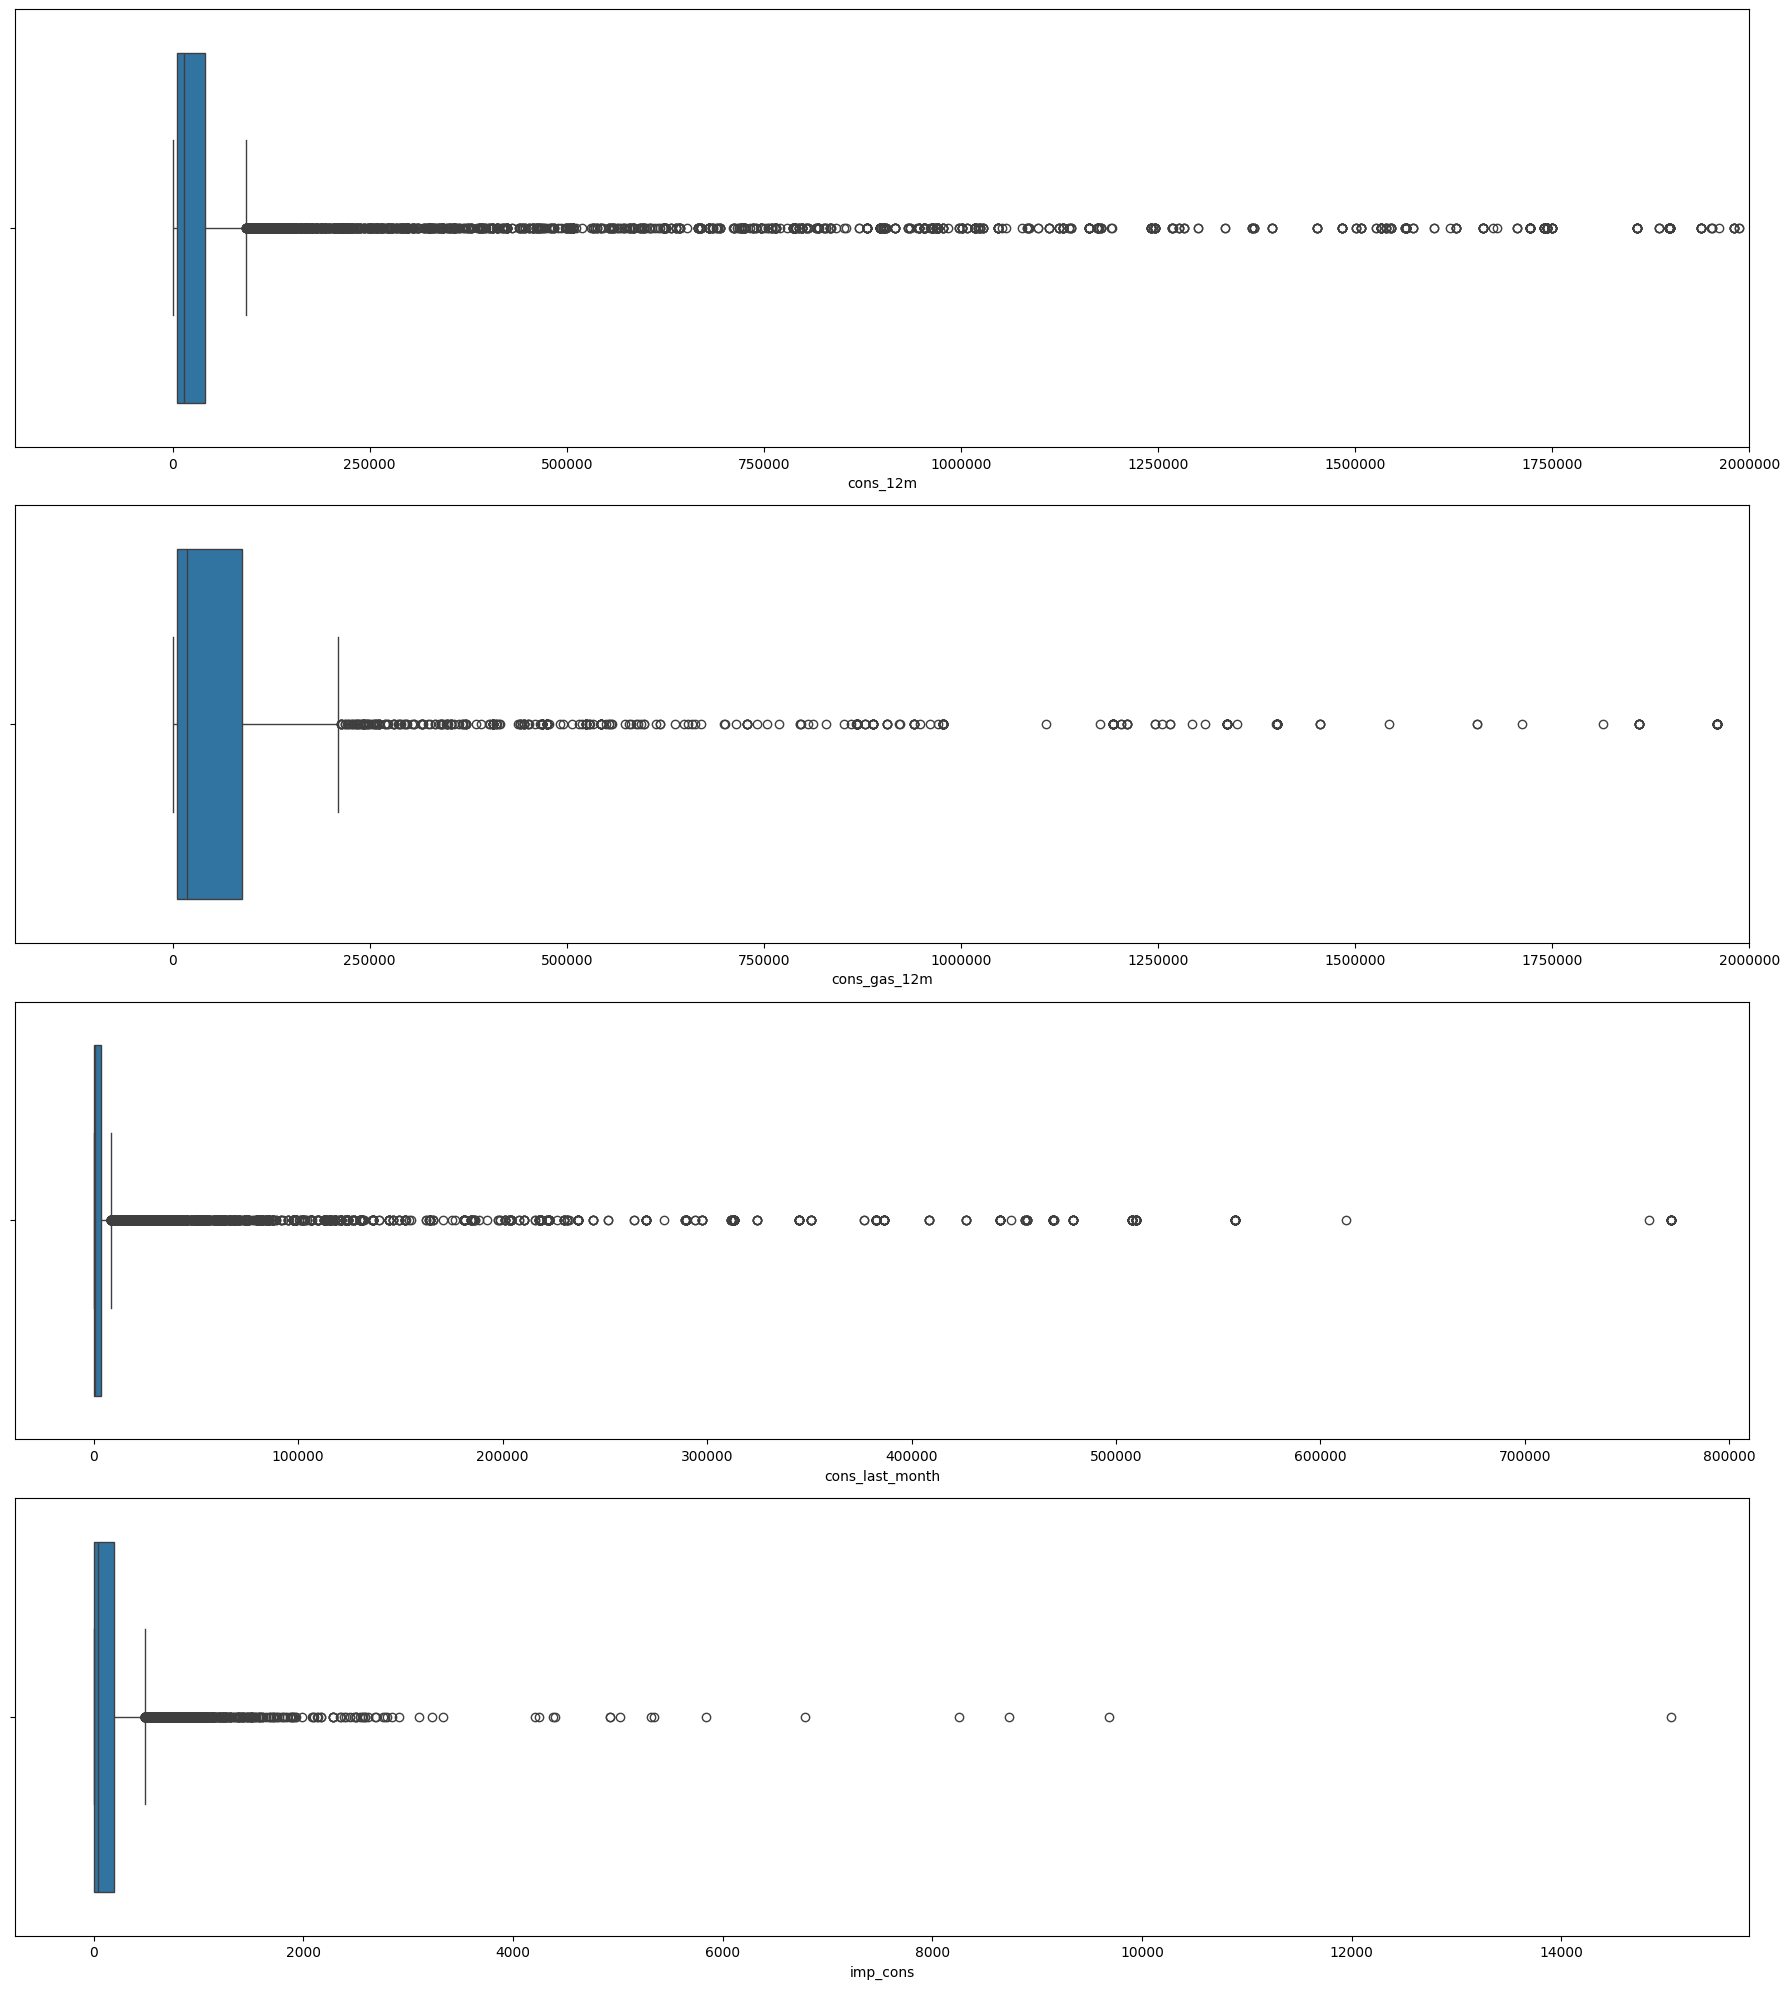

In [18]:
# Visualizing Box Plot for Understanding Outlier and Skewness
fig, axs = plt.subplots(nrows=4, figsize=(18, 20))
sns.boxplot(x=consumption["cons_12m"], ax=axs[0])

gas_consumption = consumption[consumption["has_gas"] == "t"]["cons_gas_12m"]
sns.boxplot(x=gas_consumption, ax=axs[1])
sns.boxplot(x=consumption["cons_last_month"], ax=axs[2])
sns.boxplot(x=consumption["imp_cons"], ax=axs[3])

for ax in axs:
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='x')

axs[0].set_xlim(-200000, 2000000)
axs[1].set_xlim(-200000, 2000000)

plt.tight_layout()
plt.show()

From all consumption features, we know that all features are extreme skewed and need further engineering (capping with IQR 3 Fold) before implementing on a model.

---
### Forecast Features

In [19]:
# Forecast Features
forecast = df_eda[
    ["id", "forecast_cons_12m",
    "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m",
    "forecast_price_energy_off_peak","forecast_price_energy_peak",
    "forecast_price_pow_off_peak","churn"
    ]
]

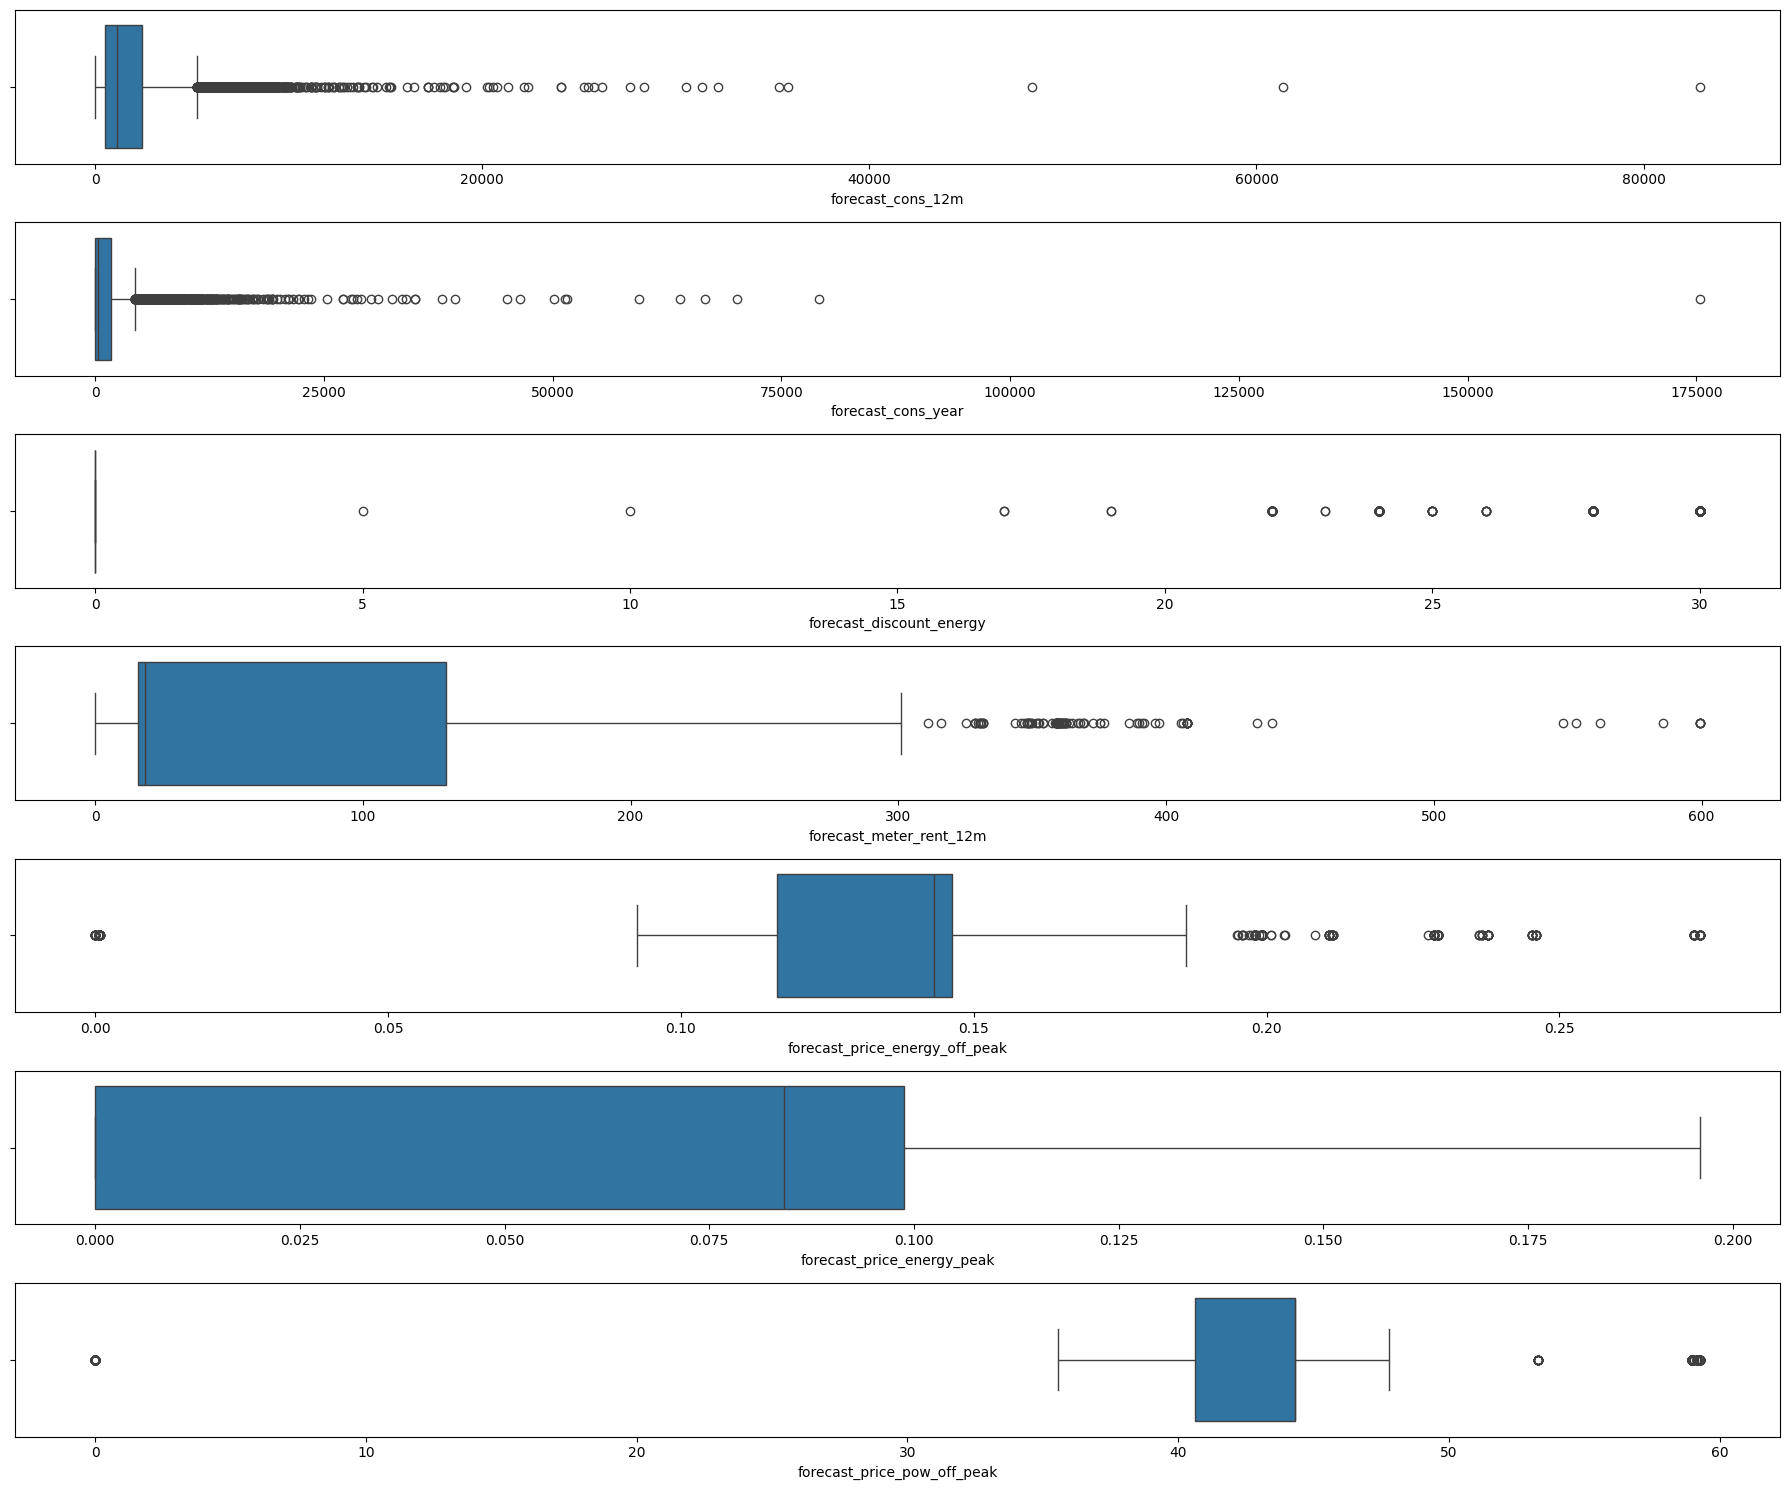

In [20]:
# Visualizing Box Plot for Understanding Skewness and Outlier
fig, axs = plt.subplots(nrows=7, figsize=(18, 15))

sns.boxplot(x=forecast["forecast_cons_12m"], ax=axs[0])
sns.boxplot(x=forecast["forecast_cons_year"], ax=axs[1])
sns.boxplot(x=forecast["forecast_discount_energy"], ax=axs[2])
sns.boxplot(x=forecast["forecast_meter_rent_12m"], ax=axs[3])
sns.boxplot(x=forecast["forecast_price_energy_off_peak"], ax=axs[4])
sns.boxplot(x=forecast["forecast_price_energy_peak"], ax=axs[5])
sns.boxplot(x=forecast["forecast_price_pow_off_peak"], ax=axs[6])

for ax in axs:
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

From the information above, we know:
1. `forecast_cons_12m`, `forecast_cons_year`, `forecast_meter_rent_12m` are extreme skewed and will be capped based on IQR (Fold 3)
2. `forecast_price_energy_off_peak`, `forecast_price_pow_off_peak` are medium skewed and will be capped based on IQR (Fold 1.5)
3. `forecast_price_energy_peak`, `forecast_discount_energy` are skewed but these are special because capping could be destroy the data

---
### Margins

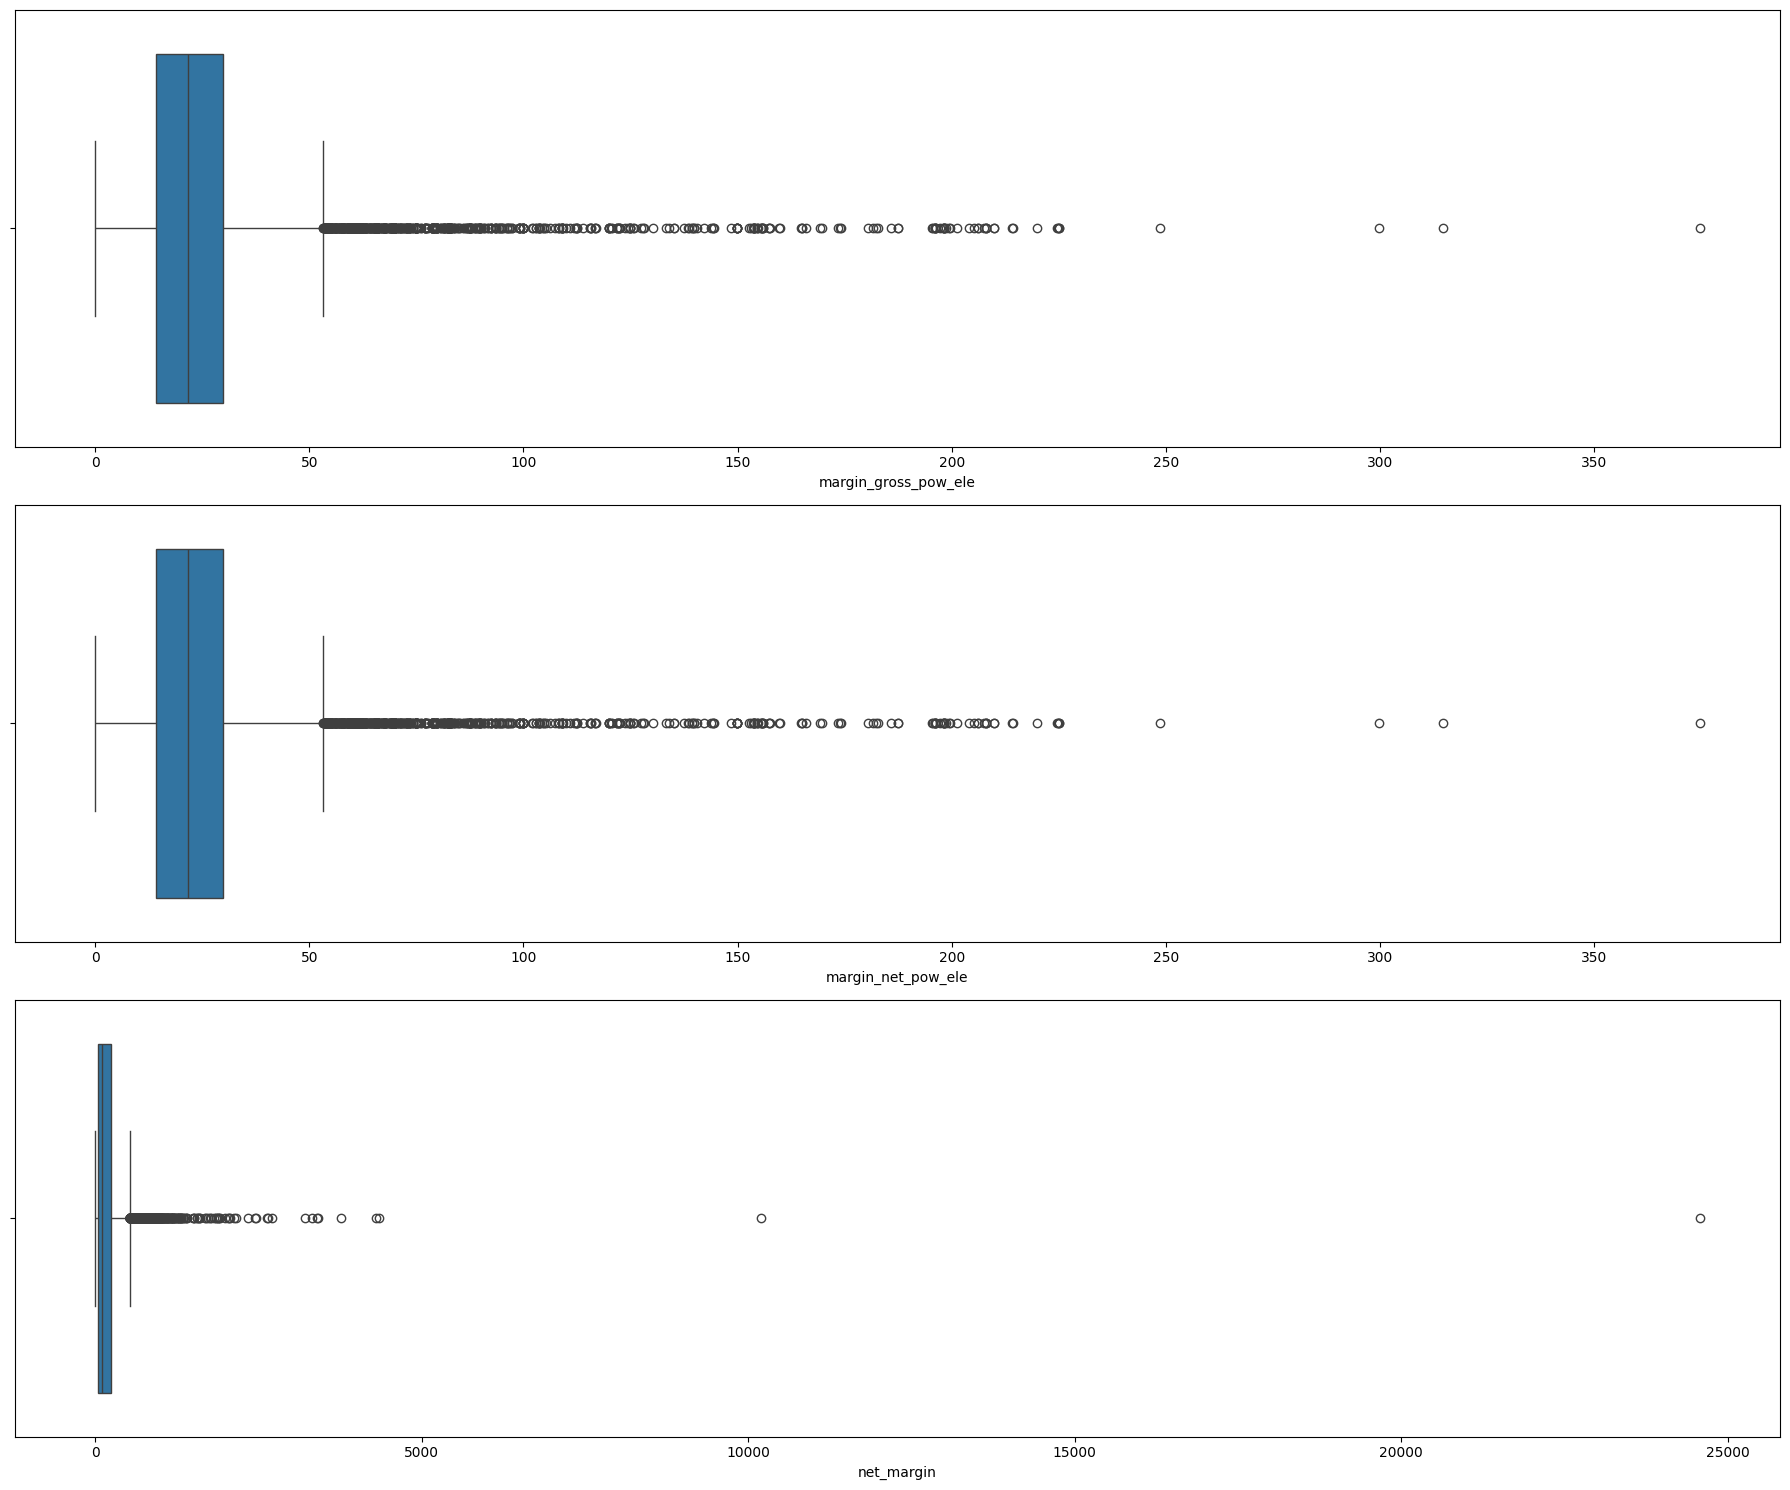

In [21]:
# Visualizing Box Plot for Understanding Skewness and Outlier
margin = df_eda[['id', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']]

fig, axs = plt.subplots(nrows=3, figsize=(18, 15))

sns.boxplot(x=margin["margin_gross_pow_ele"], ax=axs[0])
sns.boxplot(x=margin["margin_net_pow_ele"], ax=axs[1])
sns.boxplot(x=margin["net_margin"], ax=axs[2])

for ax in axs:
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

From all margin features, we know that all features are extreme skewed and need further engineering (capping with IQR 3 Fold) before implementing on a model.

---
# III. Feature Engineering

## a. Initial Engineering

In [22]:
# Checking Disguised Data
print(f"Total Customer on Client Dataset {client_df['id'].nunique()}")
print(f"Total Customer on Price Dataset {price_df['id'].nunique()}")

Total Customer on Client Dataset 14606
Total Customer on Price Dataset 16096


In [23]:
price_df = price_df[price_df['id'].isin(client_df['id'])]

In [24]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
client_df =  pd.merge(client_df, diff, on="id")


# Aggregate average prices per period by company
mean_prices = price_df.groupby(['id']).agg({
    'price_off_peak_var': 'mean', 
    'price_peak_var': 'mean', 
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'    
}).reset_index()

# Calculate the mean difference between consecutive periods
mean_prices['off_peak_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_peak_var']
mean_prices['peak_mid_peak_var_mean_diff'] = mean_prices['price_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_mid_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_peak_fix']
mean_prices['peak_mid_peak_fix_mean_diff'] = mean_prices['price_peak_fix'] - mean_prices['price_mid_peak_fix']
mean_prices['off_peak_mid_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_mid_peak_fix']

columns = [
    'id', 
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff', 
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff', 
    'peak_mid_peak_fix_mean_diff', 
    'off_peak_mid_peak_fix_mean_diff'
]
client_df = pd.merge(client_df, mean_prices[columns], on='id')


# Calculate the maximum monthly difference across time periods
max_diff_across_periods_months = mean_prices.groupby(['id']).agg({
    'off_peak_peak_var_mean_diff': 'max',
    'peak_mid_peak_var_mean_diff': 'max',
    'off_peak_mid_peak_var_mean_diff': 'max',
    'off_peak_peak_fix_mean_diff': 'max',
    'peak_mid_peak_fix_mean_diff': 'max',
    'off_peak_mid_peak_fix_mean_diff': 'max'
}).reset_index().rename(
    columns={
        'off_peak_peak_var_mean_diff': 'off_peak_peak_var_max_monthly_diff',
        'peak_mid_peak_var_mean_diff': 'peak_mid_peak_var_max_monthly_diff',
        'off_peak_mid_peak_var_mean_diff': 'off_peak_mid_peak_var_max_monthly_diff',
        'off_peak_peak_fix_mean_diff': 'off_peak_peak_fix_max_monthly_diff',
        'peak_mid_peak_fix_mean_diff': 'peak_mid_peak_fix_max_monthly_diff',
        'off_peak_mid_peak_fix_mean_diff': 'off_peak_mid_peak_fix_max_monthly_diff'
    }
)

columns = [
    'id',
    'off_peak_peak_var_max_monthly_diff',
    'peak_mid_peak_var_max_monthly_diff',
    'off_peak_mid_peak_var_max_monthly_diff',
    'off_peak_peak_fix_max_monthly_diff',
    'peak_mid_peak_fix_max_monthly_diff',
    'off_peak_mid_peak_fix_max_monthly_diff'
]

client_df = pd.merge(client_df, max_diff_across_periods_months[columns], on='id')

In [25]:
# Train, Validation, Test Splitting
X = client_df.drop(['churn'], axis = 1)
y = client_df['churn']  

In [26]:
# Splitting Train and Test Dataset
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=0.3, random_state=10)
X_val, X_test_inf, y_val, y_test_inf = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=10)
X_test, X_inf, y_test, y_inf = train_test_split(X_test_inf, y_test_inf, test_size=0.01, random_state=10)

### Categorical Transformation

In [27]:
print(X['channel_sales'].value_counts())
print(X['origin_up'].value_counts())

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64


In [28]:
def transform_categorical_features(X):
    channel_mapping = {
        'foosdfpfkusacimwkcsosbicdxkicaua': 'Direct Sales',
        'usilxuppasemubllopkaafesmlibmsdf': 'Online',
        'lmkebamcaaclubfxadlmueccxoimlema': 'Broker',
        'ewpakwlliwisiwduibdlfmalxowmwpci': 'Telesales',
        'epumfxlbckeskwekxbiuasklxalciiuu': 'Referal',
        'fixdbufsefwooaasfcxdxadsiekoceaa': 'Referal',
        'sddiedcslfslkckwlfkdpoeeailfpeds': 'Referal',
        'MISSING': 'Unknown'
    }
    X['channel_sales'] = X['channel_sales'].replace(channel_mapping)
    
    origin_mapping = {
        'kamkkxfxxuwbdslkwifmmcsiusiuosws': 'A',
        'lxidpiddsbxsbosboudacockeimpuepw': 'B',
        'ldkssxwpmemidmecebumciepifcamkci': 'C',
        'MISSING': 'D',
        'usapbepcfoloekilkwsdiboslwaxobdp': 'D',
        'ewxeelcelemmiwuafmddpobolfuxioce': 'D' 
    }
    X['origin_up'] = X['origin_up'].replace(origin_mapping)
    
    return X

categorical_trans = FunctionTransformer(transform_categorical_features)

## b. Data Type Transformation

In [29]:
# Data Type Transformation
def data_type_tr(X):
    X["date_activ"] = pd.to_datetime(X["date_activ"], format='%Y-%m-%d')
    X["date_end"] = pd.to_datetime(X["date_end"], format='%Y-%m-%d')
    X["date_modif_prod"] = pd.to_datetime(X["date_modif_prod"], format='%Y-%m-%d')
    X["date_renewal"] = pd.to_datetime(X["date_renewal"], format='%Y-%m-%d')
    return X

data_type_trans = FunctionTransformer(data_type_tr)

## c. Feature Transformation

### Transforming dates into months

In [30]:
def generate_date_features(X):
    date_columns = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
    ref_date = datetime(2016, 1, 1)
    for col in date_columns:
        dates = pd.to_datetime(X[col])
        year_diff = ref_date.year - dates.dt.year
        month_diff = ref_date.month - dates.dt.month
        months = year_diff * 12 + month_diff
        months -= (ref_date.day < dates.dt.day).astype(int)
        
        if col == 'date_activ':
            X['months_activ'] = months
        elif col == 'date_end':
            X['months_to_end'] = -months
        elif col == 'date_modif_prod':
            X['months_modif_prod'] = months
        elif col == 'date_renewal':
            X['months_renewal'] = months
    
    remove = [
            'date_activ',
            'date_end',
            'date_modif_prod',
            'date_renewal',
            'id',
            ]

    X = X.drop(columns=remove)
            
    return X

date_feature=FunctionTransformer(generate_date_features)

In [31]:
X_val.columns.to_list()

['id',
 'channel_sales',
 'cons_12m',
 'cons_gas_12m',
 'cons_last_month',
 'date_activ',
 'date_end',
 'date_modif_prod',
 'date_renewal',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak',
 'has_gas',
 'imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'origin_up',
 'pow_max',
 'offpeak_diff_dec_january_energy',
 'offpeak_diff_dec_january_power',
 'off_peak_peak_var_mean_diff',
 'peak_mid_peak_var_mean_diff',
 'off_peak_mid_peak_var_mean_diff',
 'off_peak_peak_fix_mean_diff',
 'peak_mid_peak_fix_mean_diff',
 'off_peak_mid_peak_fix_mean_diff',
 'off_peak_peak_var_max_monthly_diff',
 'peak_mid_peak_var_max_monthly_diff',
 'off_peak_mid_peak_var_max_monthly_diff',
 'off_peak_peak_fix_max_monthly_diff',
 'peak_mid_peak_fix_max_monthly_diff',
 'off_peak_mid_peak_fix_max_monthly_diff

## d. Data Balancing

In [32]:
# Data balancing using SMOTENC
smotenc = SMOTENC([0,11,18], random_state = 38)

## e. Transforming Features

### Transforming Categorical Data (Encoding)

In [33]:
# Feature engineering for nominal columns
nom_cols = ['channel_sales',
            'origin_up']
nom_pipe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
bin_cols = ['has_gas']
bin_pipe = OrdinalEncoder()

### Transforming Numerical Data (Capping, Scaling and PCA)

In [34]:
# Feature engineering for numerical columns
ex_skew_cols=['cons_12m',
              'cons_last_month',
              'imp_cons',
              'pow_max',
              'forecast_meter_rent_12m',
              'forecast_cons_year',
              'forecast_cons_12m']
med_skew_cols=['forecast_price_pow_off_peak',
               'forecast_price_energy_off_peak']
norm_skew_cols=['forecast_price_energy_peak',
                'cons_gas_12m',
                'forecast_discount_energy',
                'num_years_antig',
                'net_margin',
                'nb_prod_act',
                'margin_net_pow_ele',
                'margin_gross_pow_ele',
                'off_peak_peak_var_max_monthly_diff',
                'peak_mid_peak_var_max_monthly_diff',
                'off_peak_mid_peak_var_max_monthly_diff',
                'off_peak_peak_fix_max_monthly_diff',
                'peak_mid_peak_fix_max_monthly_diff',
                'off_peak_mid_peak_fix_max_monthly_diff',
                'off_peak_peak_var_mean_diff',
                'peak_mid_peak_var_mean_diff', 
                'off_peak_mid_peak_var_mean_diff',
                'off_peak_peak_fix_mean_diff', 
                'peak_mid_peak_fix_mean_diff',
                'off_peak_mid_peak_fix_mean_diff',
                'offpeak_diff_dec_january_energy',
                'offpeak_diff_dec_january_power',
                'months_activ',
                'months_to_end',
                'months_modif_prod',
                'months_renewal'
                ]
ex_skew_num = make_pipeline(Winsorizer(capping_method='iqr',                       
                                        tail='both',
                                        fold=3,
                                        missing_values='ignore'),
                            MinMaxScaler())
med_skew_num = make_pipeline(Winsorizer(capping_method='iqr',                       
                                        tail='both',
                                        fold=1.5,
                                        missing_values='ignore'),
                            MinMaxScaler()) 
norm_skew_num = MinMaxScaler()

preprocessor = ColumnTransformer([
    ('nom_encoding', nom_pipe, nom_cols),
    ('bin_encoding', bin_pipe, bin_cols),
    ('ex_skew', ex_skew_num, ex_skew_cols),
    ('med_skew', med_skew_num, med_skew_cols),
    ('norm_skew', norm_skew_num, norm_skew_cols) 
])

# IV. Model Validation

In [35]:
# Cross Validation
knn = imbl_make_pipeline(categorical_trans, data_type_trans, date_feature,smotenc, preprocessor, KNeighborsClassifier())
svc = imbl_make_pipeline(categorical_trans, data_type_trans, date_feature,smotenc, preprocessor, SVC(probability=True))
dt = imbl_make_pipeline(categorical_trans, data_type_trans, date_feature,smotenc, preprocessor,  DecisionTreeClassifier())
rf = imbl_make_pipeline(categorical_trans, data_type_trans, date_feature,smotenc, preprocessor,  RandomForestClassifier())
xgb = imbl_make_pipeline(categorical_trans, data_type_trans, date_feature,smotenc, preprocessor,  XGBClassifier())

models = {
    'KNN': knn,
    'SVC': svc,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb}

metrics = ['precision', 'recall', 'f1']
final_results = []

for name, model in models.items():
    scores = cross_validate(model, X_val, y_val, scoring=metrics, cv=5)
    
    final_results.append({
        'Model': name,
        'Precision (Mean)': scores['test_precision'].mean(),
        'Precision (Std)': scores['test_precision'].std(),
        'Recall (Mean)': scores['test_recall'].mean(),
        'Recall (Std)': scores['test_recall'].std(),
        'F1-Score (Mean)': scores['test_f1'].mean(),
        'F1-Score (Std)': scores['test_f1'].std()
    })

df_comparison = pd.DataFrame(final_results).sort_values(by='Precision (Mean)', ascending=False)
df_comparison

c:\Users\DELL\anaconda3\envs\h8_env\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\DELL\anaconda3\envs\h8_env\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
c:\Users\DELL\anaconda3\envs\h8_env\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\DELL\anaconda3\envs\h8_env\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.wa

,Model,Precision (Mean),Precision (Std),Recall (Mean),Recall (Std),F1-Score (Mean),F1-Score (Std)
4,XGBoost,0.300823,0.087797,0.125758,0.040585,0.176470,0.053976
3,Random Forest,0.277694,0.117016,0.071919,0.038265,0.111230,0.054181
1,SVC,0.143158,0.009921,0.392121,0.033184,0.209486,0.013610
0,KNN,0.142985,0.028883,0.310202,0.062767,0.195361,0.038688
2,Decision Tree,0.117773,0.020132,0.189091,0.033216,0.144448,0.023557


# V. Model Training

In [36]:
# Hyperparameter Design
search_params_xgb = {
    'xgbclassifier__max_depth': [3, 4, 5, 6],
    'xgbclassifier__min_child_weight': [5, 10, 15],
    'xgbclassifier__gamma': [0.5, 1, 2, 5],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__n_estimators': [500, 1000, 1500],
    'xgbclassifier__subsample': [0.6, 0.7, 0.8],
    'xgbclassifier__colsample_bytree': [0.6, 0.7, 0.8],
    'xgbclassifier__reg_alpha': [0, 0.1, 1, 10],
    'xgbclassifier__reg_lambda': [1, 2, 5, 10],
}

# Hyperparameter Tuning
final_model = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=search_params_xgb,
    n_iter=100,
    cv=3,
    random_state=20,
    n_jobs=-1,
    scoring='precision')

# Training Data
final_model.fit(X_train, y_train)

c:\Users\DELL\anaconda3\envs\h8_env\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\DELL\anaconda3\envs\h8_env\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('functiontransformer-1',
                                              FunctionTransformer(func=<function transform_categorical_features at 0x000001B339A01280>)),
                                             ('functiontransformer-2',
                                              FunctionTransformer(func=<function data_type_tr at 0x000001B339A01160>)),
                                             ('functiontransformer-3',
                                              FunctionTransformer(func=<function generate_date_features at 0x000001B...
                                        'xgbclassifier__gamma': [0.5, 1, 2, 5],
                                        'xgbclassifier__learning_rate': [0.01,
                                                                         0.05,
                                                                         0.1],
                                        'xgbclassifier__max_depth': [3, 4, 5,
                                                                     6],
                                        'xgbclassifier__min_child_weight': [5,
                                                                            10,
                                                                            15],
                                        'xgbclassifier__n_estimators': [500,
                                                                        1000,
                                                                        1500],
                                        'xgbclassifier__reg_alpha': [0, 0.1, 1,
                                                                     10],
                                        'xgbclassifier__reg_lambda': [1, 2, 5,
                                                                      10],
                                        'xgbclassifier__subsample': [0.6, 0.7,
                                                                     0.8]},
                   random_state=20, scoring='precision')

In [37]:
# Display the best hyperparameter set
display(final_model.best_params_)

# Define the best model with the best hyperparameter set
final_model_best = final_model.best_estimator_

{'xgbclassifier__subsample': 0.8,
 'xgbclassifier__reg_lambda': 2,
 'xgbclassifier__reg_alpha': 1,
 'xgbclassifier__n_estimators': 500,
 'xgbclassifier__min_child_weight': 5,
 'xgbclassifier__max_depth': 5,
 'xgbclassifier__learning_rate': 0.1,
 'xgbclassifier__gamma': 1,
 'xgbclassifier__colsample_bytree': 0.8}

# VI. Model Evaluation & Understanding

Train
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9222
           1       0.94      0.49      0.65      1002

    accuracy                           0.95     10224
   macro avg       0.95      0.74      0.81     10224
weighted avg       0.95      0.95      0.94     10224


Test
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1977
           1       0.43      0.16      0.23       192

    accuracy                           0.91      2169
   macro avg       0.68      0.57      0.59      2169
weighted avg       0.88      0.91      0.89      2169


Confusion Matrix


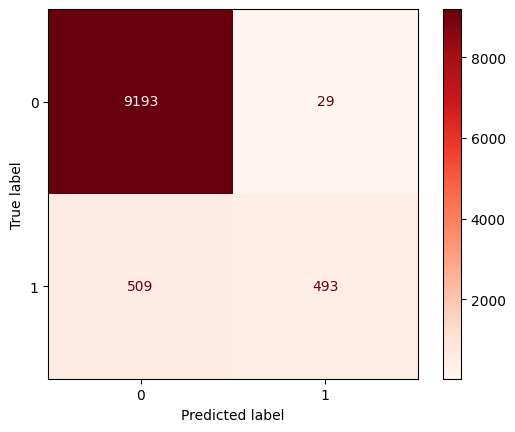

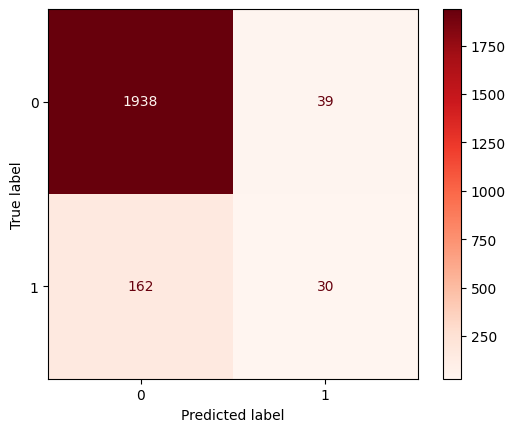

In [38]:
# Checking The Best Model Performance
y_pred_train = final_model_best.predict(X_train)
y_pred_test = final_model_best.predict(X_test)

print('Train')
print(classification_report(y_train, y_pred_train))
print()
print('Test')
print(classification_report(y_test, y_pred_test))
print()
print('Confusion Matrix')
print(ConfusionMatrixDisplay.from_estimator(final_model_best, X_train, y_train, cmap='Reds'))
print(ConfusionMatrixDisplay.from_estimator(final_model_best, X_test, y_test, cmap='Reds'))

AUC Score :  0.6576014795144158


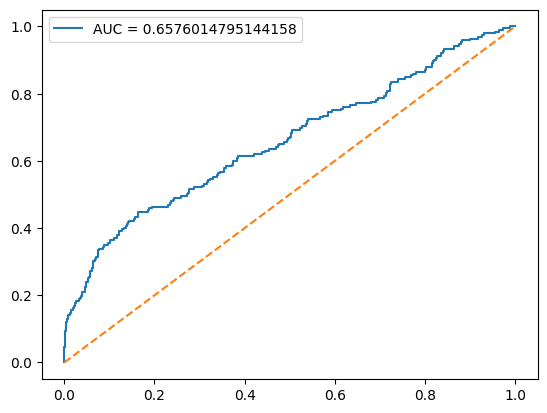

In [39]:
# Calculating AUC
y_pred_final = final_model_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_pred_final)
print('AUC Score : ', auc)

# Visualizing ROC-AUC Curve
plt.figure(0).clf()
plt.plot(fpr, tpr, label='AUC = ' + str(auc))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend(loc=0)

In [40]:
xgb_model = final_model_best.named_steps['xgbclassifier']
column_transformer = final_model_best.named_steps['columntransformer']

# Transform data
X_test_transformed = column_transformer.transform(X_train)

# Manual feature names
feature_names = []

nom_encoder = column_transformer.named_transformers_['nom_encoding']
nom_features = list(nom_encoder.get_feature_names_out(['channel_sales', 'origin_up']))
feature_names.extend(nom_features)

feature_names.append('has_gas')

num_features = ['cons_12m', 'cons_last_month', 'imp_cons', 'pow_max',
                'forecast_meter_rent_12m', 'forecast_cons_year', 'forecast_cons_12m',
                'forecast_price_pow_off_peak', 'forecast_price_energy_off_peak',
                'forecast_discount_energy', 'num_years_antig', 'net_margin',
                'nb_prod_act', 'margin_net_pow_ele', 'margin_gross_pow_ele',
                'off_peak_peak_var_max_monthly_diff', 'peak_mid_peak_var_max_monthly_diff',
                'off_peak_mid_peak_var_max_monthly_diff', 'peak_mid_peak_fix_max_monthly_diff',
                'off_peak_peak_fix_max_monthly_diff', 'off_peak_mid_peak_fix_max_monthly_diff',
                'peak_mid_peak_var_mean_diff', 'off_peak_peak_var_mean_diff',
                'off_peak_peak_fix_mean_diff', 'peak_mid_peak_fix_mean_diff',
                'off_peak_mid_peak_var_mean_diff', 'off_peak_mid_peak_fix_mean_diff',
                'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power',
                'months_activ', 'months_to_end', 'months_modif_prod', 'months_renewal']

feature_names.extend(num_features)

print(f"Total feature names: {len(feature_names)}")
print(f"Total transformed features: {X_test_transformed.shape[1]}")

if len(feature_names) != X_test_transformed.shape[1]:
    print(f"⚠️ Warning: Mismatch! Using only first {X_test_transformed.shape[1]} names")
    feature_names = feature_names[:X_test_transformed.shape[1]]

X_val_df = pd.DataFrame(X_test_transformed, columns=feature_names)

sample_size = min(1000, len(X_val_df))
X_sample = X_val_df.sample(n=sample_size, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20, show=False)
plt.title('SHAP Feature Importance - Top 20', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Feature Impact - Top 20', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("SHAP Features:")
shap_importance

Total feature names: 44
Total transformed features: 46
⚠️ Warning: Mismatch! Using only first 46 names


ValueError: Shape of passed values is (10224, 46), indices imply (10224, 44)

# VII. Model Saving

In [ ]:
# Saving Model
with open('final_model.pkl', 'wb') as a:
    dill.dump(final_model_best, a)

# VIII. Model Inference

In [ ]:
# Load Model
with open('final_model.pkl', 'rb') as f:
    final_model = dill.load(f)

In [ ]:
# Predict Data Inference
pred_inf = final_model.predict(X_inf)
X_inf['Prediction']=pred_inf
X_inf

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff,months_activ,months_to_end,months_modif_prod,months_renewal,Prediction
4542,cc799ae15a5d0dbc73f34a28eb21e8a1,Direct Sales,25983,34551,0,2011-11-09,2016-11-08,2013-11-08,2015-11-09,1819.74,...,0.027866,0.046547,14.885053,7.442524,22.327577,49,11,25,1,0
9860,e54283f956d3de76d866711b96043218,Telesales,7293,0,1139,2010-10-29,2016-10-29,2010-10-29,2015-10-30,1095.03,...,0.000000,0.149953,44.463227,0.000000,44.463227,62,10,62,2,0
7851,425b5978d48d1880241fbbca1131b66d,Unknown,107116,181160,7509,2009-08-03,2016-08-03,2009-08-03,2015-08-04,2224.11,...,0.029555,0.050171,16.248112,8.124054,24.372166,76,8,76,4,0
4701,85c1c25c1c85c48d822062e32fc7420a,Broker,50997,0,5493,2012-07-09,2016-07-08,2013-09-16,2015-07-09,4292.44,...,0.029554,0.050170,16.248113,8.124054,24.372167,41,7,27,5,0
6681,caf9cc87e4846edb6c190e13ed70afda,Broker,5731448,0,771203,2011-07-14,2016-07-14,2011-07-14,2015-07-15,2764.20,...,0.029482,0.050076,16.291555,8.145775,24.437330,53,7,53,5,0
8077,4341dce2261dc0ecf2b401e4b682c1f1,Broker,112340,0,13708,2011-01-31,2016-01-31,2011-01-31,2015-02-05,903.07,...,0.007124,0.149222,44.266930,0.000000,44.266930,59,1,59,10,0
79,cfc1377e09c9866fae771bb4180f026a,Telesales,4077,0,668,2010-07-09,2016-07-09,2015-05-23,2015-07-10,601.62,...,0.000000,0.147622,44.341005,0.000000,44.341005,65,7,7,5,0
462,0cf2b0d0f107bd05dcba322bfcdb888d,Broker,1240756,0,123925,2010-05-03,2016-05-03,2010-05-03,2015-05-04,4411.22,...,0.086483,0.168054,44.370635,0.000000,44.370635,67,5,67,7,0
11561,f69bf1282cb84b75629311bdac0a1156,Telesales,36,0,0,2012-01-20,2017-01-20,2012-01-20,2016-01-21,5.40,...,0.000000,0.150643,44.266930,0.000000,44.266930,47,13,47,-1,0
1986,cc8e5e7a597b2e87a432d67f10363341,Direct Sales,14345,0,2613,2012-10-18,2016-10-18,2015-08-27,2015-10-19,585.71,...,0.000000,0.148992,44.605820,0.000000,44.605820,38,10,4,2,0


In [ ]:
# Proportion of Prediction Result
X_inf['Prediction'].value_counts()

Prediction
0    22
Name: count, dtype: int64